In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score
from sklearn.metrics import root_mean_squared_error, mean_absolute_error

In [2]:
df = pd.read_csv("../data/processed/calfire_all_ds_joined.csv")

In [3]:
# Adding instantaneous weather variables
instantaneous_weather_df = pd.read_csv("../data/interim/calfire_weather_instantaneous.csv")
instantaneous_weather_df = instantaneous_weather_df[['incident_id','pr_incident_start', 'rmax_incident_start', 'rmin_incident_start',
       'sph_incident_start', 'srad_incident_start', 'th_incident_start',
       'tmmn_incident_start', 'tmmx_incident_start', 'vs_incident_start',
       'bi_incident_start', 'fm100_incident_start', 'fm1000_incident_start',
       'erc_incident_start', 'etr_incident_start', 'pet_incident_start',
       'vpd_incident_start', 'th_sin_incident_start', 'th_cos_incident_start']].copy()
instantaneous_weather_df = instantaneous_weather_df.rename(
        columns={
            col: f"weather_{col}"
            for col in instantaneous_weather_df.columns
            if col != "incident_id"
        }
    )

In [4]:
instantaneous_weather_df.columns

Index(['incident_id', 'weather_pr_incident_start',
       'weather_rmax_incident_start', 'weather_rmin_incident_start',
       'weather_sph_incident_start', 'weather_srad_incident_start',
       'weather_th_incident_start', 'weather_tmmn_incident_start',
       'weather_tmmx_incident_start', 'weather_vs_incident_start',
       'weather_bi_incident_start', 'weather_fm100_incident_start',
       'weather_fm1000_incident_start', 'weather_erc_incident_start',
       'weather_etr_incident_start', 'weather_pet_incident_start',
       'weather_vpd_incident_start', 'weather_th_sin_incident_start',
       'weather_th_cos_incident_start'],
      dtype='str')

In [5]:
# Trying out using the landfire dataset
landfire_df = pd.read_csv("../data/raw/calfire_fuels.csv")

In [6]:
# Get latitude/longitude

calfire_df = pd.read_csv("../data/interim/calfire.csv")

In [7]:
# Add latitude/longitude

print(df.shape)

df = df.merge(
    calfire_df[
        [
            "incident_id",
            "incident_latitude",
            "incident_longitude"
        ]
    ].drop_duplicates(subset="incident_id"),
    how="left",
    left_on="fire_incident_id",
    right_on="incident_id"
).drop(columns="incident_id")
print(df.shape)

(3439, 108)
(3439, 110)


In [8]:
# Add fuels data

df = df.merge(
    landfire_df[
        [
            "incident_id",
            "fuel_fbfm40_code"
        ]
    ].drop_duplicates(subset="incident_id"),
    how="left",
    left_on="fire_incident_id",
    right_on="incident_id"
).drop(columns="incident_id")
print(df.shape)

(3439, 111)


In [9]:
# Add instantaneous weather data

df = df.merge(
    instantaneous_weather_df.drop_duplicates(subset="incident_id"),
    how="left",
    left_on="fire_incident_id",
    right_on="incident_id"
).drop(columns="incident_id")
print(df.shape)

(3439, 129)


In [10]:
# filter out incorrect lat/long

df = df.rename(columns={
    "incident_latitude": "fire_incident_latitude",
    "incident_longitude": "fire_incident_longitude"
})

df = df[
    df["fire_incident_latitude"].between(32, 50)
    & df["fire_incident_longitude"].between(-125, -114)
].copy()

In [11]:
# extract month from fire created date

df["fire_incident_date_created"] = pd.to_datetime(
    df["fire_incident_date_created"],
    errors="coerce"
)
df['fire_start_month'] = df['fire_incident_date_created'].dt.month

# one-hot encode the months
month_dummies = pd.get_dummies(
    df["fire_start_month"],
    prefix="fire_start_month",
    drop_first=True,
    dtype=int
)

df = pd.concat(
    [df.drop(columns="fire_start_month"), month_dummies],
    axis=1
)

In [12]:
# add log transform to target
df['log_acres_burned'] = np.log1p(df['fire_incident_acres_burned'])
df_copy = df.copy()

# add fuel type and variation together
df["vegetation_fuel_type_and_variation"] = (
    df["vegetation_fuel_type"].str.cat(
        df["vegetation_fuel_variation"],
        sep="_"
    )
)

df.drop(
    columns=[
        "vegetation_fuel_type",
        "vegetation_fuel_variation"
    ],
    inplace=True
)

# drop other fire columns that aren't relevant
df = df.drop(
    columns=[
        "fire_incident_id",
        "fire_incident_date_created",
        "fire_incident_date_last_update",
        "fire_incident_acres_burned"
    ],
    errors="ignore"
)

print(df.shape)

(3421, 136)


In [13]:
# Extract categorical columns for one-hot encoding

categorical_cols = df.select_dtypes(
    include=["object", "category", "string", "bool"]
).columns.tolist()

categorical_cols


['fire_incident_county',
 'fuel_fbfm40_code',
 'vegetation_fuel_type_and_variation']

In [14]:
# First encode <10 count ones as 'other'

for col in categorical_cols:
    counts = df[col].value_counts()
    rare = counts[counts < 10].index
    df.loc[df[col].isin(rare), col] = "Other"

In [15]:
print(df.shape)

# One hot encode the categorical variables
df = pd.get_dummies(
    df,
    columns=categorical_cols,
    drop_first=False,   # Keep all categories
    dtype=int
)

df.columns = (
    df.columns
      .str.replace(r'[^A-Za-z0-9_]', '_', regex=True)
)

print(df.shape)

(3421, 136)
(3421, 233)


In [33]:
# Function for fitting a dictionary of models
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import KFold, cross_val_score
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

def benchmark_models(
        df, 
        col_groups = None,
        other_cols_to_include = [],
        model_names = None,
        target = 'log_acres_burned', 
        test_size = 0.2, 
        random_state=42,
        weight_scheme = 'unweighted',
        return_models=False
        ):

    if col_groups is None:
        col_groups = [
            "weather",
            "drought",
            "vegetation",
            "topography",
            "spatial",
            "fire",
            "fuel"
        ]

    group_prefixes = {
        "weather": "weather_",
        "drought": "drought_",
        "vegetation": "vegetation_",
        "topography": "topography_",
        "spatial": "spatial_",
        "interaction": "interaction",
        "fire": "fire_",
        "fuel": "fuel_"
    }

    cols_to_model = []

    for group in col_groups:
        if group not in group_prefixes:
            raise ValueError(f"Unknown column group: {group}")

        prefix = group_prefixes[group]

        cols_to_model.extend(
            c for c in df.columns
            if c.startswith(prefix)
        )

    # Remove duplicates while preserving order
    feature_cols = list(dict.fromkeys(cols_to_model + other_cols_to_include))

    # Drop missing rows only for the selected features and target
    temp_df = (
        df[feature_cols + [target]]
        .dropna()
        .copy()
    )

    X = temp_df[feature_cols]
    y = temp_df[target]

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=test_size,
        random_state=random_state
    )

    cv = KFold(
        n_splits=5,
        shuffle=True,
        random_state=random_state
    )

    q80 = y_train.quantile(0.80)
    q90 = y_train.quantile(0.90)
    q95 = y_train.quantile(0.95)

    weight_schemes = {
        "unweighted": np.ones(len(y_train)),
        "mild": np.where(y_train >= q80, 1.5, 1),
        "moderate": np.where(y_train >= q80, 2, 1),
        "aggressive_top20": np.where(y_train >= q80, 5, 1),
        "very_aggressive": np.select(
            [y_train >= q95, y_train >= q90, y_train >= q80],
            [20, 10, 5],
            default=1
        )
    }

    if weight_scheme not in weight_schemes:
        raise ValueError(
            f"Unknown weight scheme: {weight_scheme}. "
            f"Choose from {list(weight_schemes)}"
        )

    train_weights = weight_schemes[weight_scheme]

    all_models = {
        "Linear Regression": LinearRegression(),
        "Random Forest": RandomForestRegressor(
            random_state=random_state
        ),
        "XGBoost": XGBRegressor(
            random_state=random_state,
            objective="reg:squarederror"
        ),
        "LightGBM": LGBMRegressor(
            random_state=random_state,
            verbose=-1
        )
    }

    # Run all models if none are specified
    if model_names is None:
        model_names = list(all_models.keys())

    # Allow a single model name as a string
    elif isinstance(model_names, str):
        model_names = [model_names]

    invalid_models = [
        name for name in model_names
        if name not in all_models
    ]

    if invalid_models:
        raise ValueError(
            f"Unknown models: {invalid_models}. "
            f"Choose from {list(all_models.keys())}"
        )

    models = {
        name: all_models[name]
        for name in model_names
    }
    
    results = []
    fitted_models = {}

    for name, model in models.items():
        cv_scores = cross_val_score(
            model,
            X_train,
            y_train,
            scoring="r2",
            cv=cv,
            n_jobs=-2
        )

        model.fit(X_train, y_train,sample_weight = train_weights)
        fitted_models[name] = model

        train_preds = model.predict(X_train)
        test_preds = model.predict(X_test)

        train_r2 = r2_score(y_train, train_preds)
        test_r2 = r2_score(y_test, test_preds)

        train_rmse = root_mean_squared_error(
            y_train,
            train_preds
        )
        test_rmse = root_mean_squared_error(
            y_test,
            test_preds
        )

        train_mae = mean_absolute_error(
            y_train,
            train_preds
        )
        test_mae = mean_absolute_error(
            y_test,
            test_preds
        )

        results.append({
            "Model": name,
            "Weight Scheme": weight_scheme,
            "CV R² Mean": cv_scores.mean(),
            "CV R² SD": cv_scores.std(),
            "Train R²": train_r2,
            "Test R²": test_r2,
            "R² Overfit Gap": train_r2 - test_r2,
            "Train RMSE": train_rmse,
            "Test RMSE": test_rmse,
            "RMSE Gap": test_rmse - train_rmse,
            "Train MAE": train_mae,
            "Test MAE": test_mae,
            "MAE Gap": test_mae - train_mae,
            "n_features": len(cols_to_model),
            "n_rows": len(temp_df)
        })

    results_df = (
        pd.DataFrame(results)
        .sort_values(
            ["CV R² Mean", "CV R² SD"],
            ascending=[False, True]
        )
        .reset_index(drop=True)
    )

    if return_models:
        return {
            "results": results_df,
            "models": fitted_models,
            "feature_names": feature_cols,
            "X_train": X_train,
            "X_test": X_test,
            "y_train": y_train,
            "y_test": y_test
        }
    else:
        return results_df

### Ablation study - one at a time

In [17]:
from itertools import combinations

def run_ablation(
    df,
    target="log_acres_burned",
    model_names=None,
    random_state=42,
    weight_scheme = 'unweighted'
):

    group_prefixes = {
        "weather": "weather_",
        "drought": "drought_",
        "vegetation": "vegetation_",
        "topography": "topography_",
        "spatial": "spatial_",
        "interaction": "interaction",
        "fire": "fire_",
        "fuel": "fuel_"
    }

    col_groups = [
        group
        for group, prefix in group_prefixes.items()
        if any(col.startswith(prefix) for col in df.columns)
    ]

    all_results = []

    # Generate all non-empty combinations of groups
    for r in range(1, len(col_groups) + 1):

        for combo in combinations(col_groups, r):
            print(combo)

            results_exp = benchmark_models(
                df=df,
                col_groups=list(combo),
                model_names=model_names,
                target=target,
                random_state=random_state,
                weight_scheme=weight_scheme
            )

            results_exp["Experiment"] = "_".join(combo)

            all_results.append(results_exp)

    return (
        pd.concat(all_results, ignore_index=True)
        .sort_values(
            ["CV R² Mean", "CV R² SD"],
            ascending=[False, True]
        )
        .reset_index(drop=True)
    )

In [18]:
topo_cols = [c for c in df.columns if c.startswith("topography_")]
print(topo_cols)
print(len(topo_cols))

veg_cols = [c for c in df.columns if c.startswith("vegetation_")]
print(veg_cols)
print(len(veg_cols))


spatial_cols = [c for c in df.columns if c.startswith("spatial_")]
print(spatial_cols)
print(len(spatial_cols))


drought_cols = [c for c in df.columns if c.startswith("drought_")]
print(drought_cols)
print(len(drought_cols))


weather_cols = [c for c in df.columns if c.startswith("weather_")]
print(weather_cols)
print(len(weather_cols))

fire_cols = [c for c in df.columns if c.startswith("fire_")]
print(fire_cols)
print(len(fire_cols))

fuel_cols = [c for c in df.columns if c.startswith("fuel_")]
print(fuel_cols)
print(len(fuel_cols))

['topography_aspect', 'topography_elevation', 'topography_first', 'topography_hillshade', 'topography_slope']
5
['vegetation_percent', 'vegetation_ele', 'vegetation_fuel_type_and_variation_Bitterbrush_Desert', 'vegetation_fuel_type_and_variation_Brittlebrush_Unknown', 'vegetation_fuel_type_and_variation_Buckwheat_Eastern_Mojave', 'vegetation_fuel_type_and_variation_Ceanothus_Buckbrush', 'vegetation_fuel_type_and_variation_Ceanothus_Deerbrush', 'vegetation_fuel_type_and_variation_Ceanothus_Hoaryleaf', 'vegetation_fuel_type_and_variation_Ceanothus_Whitethorn', 'vegetation_fuel_type_and_variation_Chamise_New_Growth', 'vegetation_fuel_type_and_variation_Chamise_Old_Growth', 'vegetation_fuel_type_and_variation_Chamise_Unknown', 'vegetation_fuel_type_and_variation_Douglas_Fir_Coastal', 'vegetation_fuel_type_and_variation_Douglas_Fir_Unknown', 'vegetation_fuel_type_and_variation_Mahogany_Curl_Leaf_Mountain', 'vegetation_fuel_type_and_variation_Manzanita_Bigberry', 'vegetation_fuel_type_and_va

In [19]:
ablation_unprocessed_df = run_ablation(df, target = 'log_acres_burned')
ablation_unprocessed_df


('weather',)
('drought',)
('vegetation',)
('topography',)
('spatial',)
('fire',)
('fuel',)
('weather', 'drought')
('weather', 'vegetation')
('weather', 'topography')
('weather', 'spatial')
('weather', 'fire')
('weather', 'fuel')
('drought', 'vegetation')
('drought', 'topography')
('drought', 'spatial')
('drought', 'fire')
('drought', 'fuel')
('vegetation', 'topography')
('vegetation', 'spatial')
('vegetation', 'fire')
('vegetation', 'fuel')
('topography', 'spatial')
('topography', 'fire')
('topography', 'fuel')
('spatial', 'fire')
('spatial', 'fuel')
('fire', 'fuel')
('weather', 'drought', 'vegetation')
('weather', 'drought', 'topography')
('weather', 'drought', 'spatial')
('weather', 'drought', 'fire')
('weather', 'drought', 'fuel')
('weather', 'vegetation', 'topography')
('weather', 'vegetation', 'spatial')
('weather', 'vegetation', 'fire')
('weather', 'vegetation', 'fuel')
('weather', 'topography', 'spatial')
('weather', 'topography', 'fire')
('weather', 'topography', 'fuel')
('weat

,Model,Weight Scheme,CV R² Mean,CV R² SD,Train R²,Test R²,R² Overfit Gap,Train RMSE,Test RMSE,RMSE Gap,Train MAE,Test MAE,MAE Gap,n_features,n_rows,Experiment
0,Random Forest,unweighted,0.224660,0.065680,0.892202,0.234864,0.657339,0.652017,1.853866,1.201849,0.494843,1.397231,0.902388,232,2549,weather_drought_vegetation_topography_spatial_...
1,Random Forest,unweighted,0.223555,0.063971,0.891416,0.206240,0.685176,0.654392,1.888225,1.233833,0.499653,1.427508,0.927855,207,2549,weather_drought_vegetation_topography_spatial_...
2,Random Forest,unweighted,0.222750,0.064446,0.892296,0.203495,0.688801,0.662460,1.753558,1.091098,0.505676,1.338154,0.832478,182,3375,weather_drought_topography_spatial_fire
3,Random Forest,unweighted,0.221200,0.063802,0.894852,0.203120,0.691732,0.654553,1.753971,1.099417,0.498127,1.351746,0.853620,207,3375,weather_drought_topography_spatial_fire_fuel
4,Random Forest,unweighted,0.215516,0.063638,0.891462,0.160942,0.730520,0.679922,1.770727,1.090805,0.510017,1.342229,0.832212,227,2565,weather_drought_vegetation_spatial_fire_fuel
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
503,XGBoost,unweighted,-0.161977,0.026345,0.975015,-0.045988,1.021003,0.323768,2.035011,1.711243,0.232505,1.513776,1.281271,46,2570,drought_vegetation
504,XGBoost,unweighted,-0.169273,0.046007,0.842728,-0.039204,0.881932,0.807492,2.124481,1.316988,0.590140,1.611253,1.021113,30,3421,spatial_fuel
505,XGBoost,unweighted,-0.170174,0.095861,0.942766,-0.297091,1.239857,0.486319,2.395053,1.908735,0.357410,1.749727,1.392316,30,2582,vegetation_spatial
506,XGBoost,unweighted,-0.199496,0.078234,0.865056,-0.092757,0.957814,0.732026,2.173785,1.441759,0.542046,1.634526,1.092480,5,3392,topography


Not seeing huge amounts of variation in the vegetation percent and elevation, and while fuel type + variation could be a combined variable, the tree-based models should be able to learn the interactions between them.

Next, let's look at spatial data.

I think we can do some feature reduction on the drought data.

In [20]:
# Work on a copy
df2 = df.copy()

# -------------------------
# DSCI
# -------------------------
dsci_cols = [c for c in df2.columns if c.startswith('drought_dsci_')]

df2["drought_reduced_dsci_current"] = (
    df2["drought_dsci_current"]
)

df2["drought_reduced_dsci_trend_vs_52wk"] = (
    df2["drought_dsci_current"]
    - df2["drought_dsci_52wk_avg"]
)

df2["drought_reduced_dsci_std_across_windows"] = (
    df2[dsci_cols].std(axis=1)
)

spei_cols = [c for c in df2.columns if c.startswith('drought_spei')]
df2["drought_reduced_spei180d_current"] = (
    df2["drought_spei180d_current"]
)

df2["drought_reduced_spei180d_trend_vs_4wk"] = (
    df2["drought_spei180d_current"]
    - df2["drought_spei180d_4wk_avg"]
)

df2["drought_reduced_spei180d_std_across_windows"] = (
    df2[spei_cols].std(axis=1)
)

pdsi_cols = [c for c in df2.columns if c.startswith('drought_pdsi_')]
df2["drought_reduced_pdsi_current"] = (
    df2["drought_pdsi_current"]
)

df2["drought_reduced_pdsi_trend_vs_4wk"] = (
    df2["drought_pdsi_current"]
    - df2["drought_pdsi_4wk_avg"]
)

df2["drought_reduced_pdsi_std_across_windows"] = (
    df2[pdsi_cols].std(axis=1)
)

eddi_cols = [c for c in df2.columns if c.startswith('drought_eddi')]
df2["drought_reduced_eddi90d_current"] = (
    df2["drought_eddi90d_current"]
)

df2["drought_reduced_eddi90d_trend_vs_4wk"] = (
    df2["drought_eddi90d_current"]
    - df2["drought_eddi90d_4wk_avg"]
)

df2["drought_reduced_eddi90d_std_across_windows"] = (
    df2[eddi_cols].std(axis=1)
)

reduced_drought_cols = [
    c for c in df2.columns
    if c.startswith("drought_reduced_")
]

df2.drop(columns = dsci_cols + spei_cols + eddi_cols + pdsi_cols, inplace = True)

Decided to log transform the spatial data.

In [21]:
spatial_cols = [c for c in df2.columns if c.startswith('spatial')]

for col in spatial_cols:
    df2[f"{col}_log"] = np.log1p(df2[col])

df2.drop(columns=spatial_cols, inplace = True)

Feature engineering to improve weather columns:
- Take only the recent average (2w)
- Create new variable to illustrate trend (2w-8w)
- Create new variable to illustrate variability (standard deviation across all time windows)

In [22]:
# Feature engineering
import re

def make_weather_recent_trend_variability(df):
    windows = ["2w", "4w", "6w", "8w"]

    # All weather columns
    weather_cols = [c for c in df.columns if c.startswith("weather_")]

    # Extract base weather variable names
    base_vars = sorted(set(
        re.sub(r"_(2w|4w|6w|8w)$", "", c)
        for c in weather_cols
    ))

    new_df = df.copy()

    engineered_cols = []

    for base in base_vars:
        window_cols = [f"{base}_{w}" for w in windows]

        # Only use variables that have all four windows
        if not all(c in df.columns for c in window_cols):
            continue

        recent_col = f"{base}_recent_2w"
        trend_col = f"{base}_trend_2w_minus_8w"
        variability_col = f"{base}_std_across_windows"

        new_df[recent_col] = df[f"{base}_2w"]
        new_df[trend_col] = df[f"{base}_2w"] - df[f"{base}_8w"]
        new_df[variability_col] = df[window_cols].std(axis=1)

        engineered_cols.extend([
            recent_col,
            trend_col,
            variability_col
        ])

    return new_df, engineered_cols

In [23]:
weather_cols = [c for c in df2.columns if c.startswith('weather_')]
df3, weather_cols_engr = make_weather_recent_trend_variability(df2)
df3.drop(columns = weather_cols, inplace = True)


In [24]:
ablation_study_2 = run_ablation(df3)
ablation_study_2

('weather',)
('drought',)
('vegetation',)
('topography',)
('spatial',)
('fire',)
('fuel',)
('weather', 'drought')
('weather', 'vegetation')
('weather', 'topography')
('weather', 'spatial')
('weather', 'fire')
('weather', 'fuel')
('drought', 'vegetation')
('drought', 'topography')
('drought', 'spatial')
('drought', 'fire')
('drought', 'fuel')
('vegetation', 'topography')
('vegetation', 'spatial')
('vegetation', 'fire')
('vegetation', 'fuel')
('topography', 'spatial')
('topography', 'fire')
('topography', 'fuel')
('spatial', 'fire')
('spatial', 'fuel')
('fire', 'fuel')
('weather', 'drought', 'vegetation')
('weather', 'drought', 'topography')
('weather', 'drought', 'spatial')
('weather', 'drought', 'fire')
('weather', 'drought', 'fuel')
('weather', 'vegetation', 'topography')
('weather', 'vegetation', 'spatial')
('weather', 'vegetation', 'fire')
('weather', 'vegetation', 'fuel')
('weather', 'topography', 'spatial')
('weather', 'topography', 'fire')
('weather', 'topography', 'fuel')
('weat

,Model,Weight Scheme,CV R² Mean,CV R² SD,Train R²,Test R²,R² Overfit Gap,Train RMSE,Test RMSE,RMSE Gap,Train MAE,Test MAE,MAE Gap,n_features,n_rows,Experiment
0,Random Forest,unweighted,0.206860,0.057064,0.888307,0.196195,0.692112,0.663694,1.900135,1.236441,0.505576,1.422127,0.916552,158,2549,weather_drought_vegetation_topography_fire
1,Random Forest,unweighted,0.204013,0.061517,0.889639,0.179979,0.709660,0.659724,1.919206,1.259482,0.503788,1.443072,0.939284,163,2549,weather_drought_vegetation_topography_spatial_...
2,Random Forest,unweighted,0.203150,0.065676,0.889211,0.167530,0.721682,0.671880,1.792710,1.120830,0.513816,1.377656,0.863840,138,3375,weather_drought_topography_spatial_fire
3,Random Forest,unweighted,0.202672,0.062105,0.890878,0.186074,0.704803,0.666809,1.772630,1.105822,0.508438,1.365353,0.856915,163,3375,weather_drought_topography_spatial_fire_fuel
4,LightGBM,unweighted,0.201327,0.061442,0.874661,0.161995,0.712666,0.713851,1.825701,1.111850,0.557179,1.404903,0.847725,151,3386,weather_topography_spatial_fire_fuel
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
503,XGBoost,unweighted,-0.167002,0.047148,0.842728,-0.039204,0.881932,0.807492,2.124481,1.316988,0.590140,1.611253,1.021113,30,3421,spatial_fuel
504,XGBoost,unweighted,-0.170172,0.095859,0.942265,-0.244814,1.187079,0.488445,2.346293,1.857849,0.354112,1.711473,1.357360,30,2582,vegetation_spatial
505,XGBoost,unweighted,-0.196072,0.085344,0.980867,-0.001268,0.982135,0.283326,1.991034,1.707707,0.207717,1.473661,1.265944,37,2570,drought_vegetation
506,XGBoost,unweighted,-0.199496,0.078234,0.865056,-0.092757,0.957814,0.732026,2.173785,1.441759,0.542046,1.634526,1.092480,5,3392,topography


Compressing existing information does not really seem to help, try to add additional information by creating feature interactions.

In [25]:
# # Function for running a random forest analysis
# from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# def fit_rf_for_groups(df, groups_to_use, target="log_acres_burned", random_state=42):

#     group_prefixes = {
#         "fire": "fire_",
#         "weather": "weather_",
#         "drought": "drought_",
#         "vegetation": "vegetation_",
#         "topography": "topography_",
#         "spatial": "spatial_",
#         "interaction": "interaction"
#     }

#     cols = []

#     for group in groups_to_use:
#         prefix = group_prefixes[group]
#         cols.extend([c for c in df.columns if c.startswith(prefix)])

#     cols = list(dict.fromkeys(cols))

#     temp_df = df[cols + [target]].dropna().copy()

#     X = temp_df[cols]
#     y = temp_df[target]

#     X_train, X_test, y_train, y_test = train_test_split(
#         X,
#         y,
#         test_size=0.2,
#         random_state=random_state
#     )

#     rf = RandomForestRegressor(random_state=random_state)

#     rf.fit(
#         X_train,
#         y_train)
    

#     train_preds = rf.predict(X_train)
#     preds = rf.predict(X_test) 
#     print("Train R²:", r2_score(y_train, train_preds)) 
#     print("Test R²:", r2_score(y_test, preds)) 
#     print("Rows:", len(temp_df)) 
#     print("Features:", len(cols)) 
    
#     return rf, X_train, X_test, y_train, y_test

In [26]:
best_col_groups = ablation_study_2['Experiment'].iloc[0].split("_")
best_model = ablation_study_2['Model'].iloc[0]

ablation_2_best = benchmark_models(
    df3, col_groups = best_col_groups,
    model_names=[best_model],
    return_models=True
)


In [27]:
ablation_2_best['models']

{'Random Forest': RandomForestRegressor(random_state=42)}

In [28]:
# First see what the feature importance is on the best model:
best_model = list(ablation_2_best["models"].values())[0]

best_model.fit(ablation_2_best['X_train'],ablation_2_best['y_train'])

feature_importance = (
    pd.DataFrame({
        "Feature": ablation_2_best['X_train'].columns,
        "Importance": best_model.feature_importances_
    })
    .sort_values("Importance", ascending=False)
)
feature_importance.head(20)


,Feature,Importance
133,fire_incident_county_Other,0.075600
89,topography_elevation,0.056001
90,topography_first,0.040962
52,drought_reduced_dsci_trend_vs_52wk,0.029251
93,fire_incident_latitude,0.019673
53,drought_reduced_dsci_std_across_windows,0.019272
91,topography_hillshade,0.017832
88,topography_aspect,0.017351
33,weather_th_cos_recent_2w,0.017266
55,drought_reduced_spei180d_trend_vs_4wk,0.017029


In [29]:
df4 = df3.copy()
top_features = feature_importance["Feature"].head(20).tolist()
top_features = [
    f for f in top_features
    if not f.startswith("fire_incident_county_")
]

for f1, f2 in combinations(top_features, 2):
    df4[f"interaction_{f1}_x_{f2}"] = df4[f1] * df4[f2]

/var/folders/f7/2wd1rsm1575528vljzwss8kc0000gn/T/ipykernel_67054/3979820023.py:9: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df4[f"interaction_{f1}_x_{f2}"] = df4[f1] * df4[f2]
/var/folders/f7/2wd1rsm1575528vljzwss8kc0000gn/T/ipykernel_67054/3979820023.py:9: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df4[f"interaction_{f1}_x_{f2}"] = df4[f1] * df4[f2]
/var/folders/f7/2wd1rsm1575528vljzwss8kc0000gn/T/ipykernel_67054/3979820023.py:9: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `

In [30]:
top_features

['topography_elevation',
 'topography_first',
 'drought_reduced_dsci_trend_vs_52wk',
 'fire_incident_latitude',
 'drought_reduced_dsci_std_across_windows',
 'topography_hillshade',
 'topography_aspect',
 'weather_th_cos_recent_2w',
 'drought_reduced_spei180d_trend_vs_4wk',
 'drought_reduced_dsci_current',
 'weather_sph_mean_std_across_windows',
 'weather_bi_mean_recent_2w',
 'weather_rmin_mean_recent_2w',
 'fire_incident_longitude',
 'weather_th_sin_trend_2w_minus_8w',
 'drought_reduced_pdsi_current',
 'weather_pet_mean_recent_2w',
 'weather_srad_mean_std_across_windows',
 'weather_etr_mean_recent_2w']

In [31]:
print(df3.shape)
print(df4.shape)

(3421, 189)
(3421, 360)


In [34]:
ablation_study_4 = run_ablation(df4)
ablation_study_4

('weather',)
('drought',)
('vegetation',)
('topography',)
('spatial',)
('interaction',)
('fire',)
('fuel',)
('weather', 'drought')
('weather', 'vegetation')
('weather', 'topography')
('weather', 'spatial')
('weather', 'interaction')
('weather', 'fire')
('weather', 'fuel')
('drought', 'vegetation')
('drought', 'topography')
('drought', 'spatial')
('drought', 'interaction')
('drought', 'fire')
('drought', 'fuel')
('vegetation', 'topography')
('vegetation', 'spatial')
('vegetation', 'interaction')
('vegetation', 'fire')
('vegetation', 'fuel')
('topography', 'spatial')
('topography', 'interaction')
('topography', 'fire')
('topography', 'fuel')
('spatial', 'interaction')
('spatial', 'fire')
('spatial', 'fuel')
('interaction', 'fire')
('interaction', 'fuel')
('fire', 'fuel')
('weather', 'drought', 'vegetation')
('weather', 'drought', 'topography')
('weather', 'drought', 'spatial')
('weather', 'drought', 'interaction')
('weather', 'drought', 'fire')
('weather', 'drought', 'fuel')
('weather', 

,Model,Weight Scheme,CV R² Mean,CV R² SD,Train R²,Test R²,R² Overfit Gap,Train RMSE,Test RMSE,RMSE Gap,Train MAE,Test MAE,MAE Gap,n_features,n_rows,Experiment
0,Random Forest,unweighted,0.214390,0.063630,0.890452,0.226006,0.664445,0.657291,1.864566,1.207275,0.497625,1.409322,0.911697,303,2549,drought_vegetation_spatial_interaction_fire_fuel
1,Random Forest,unweighted,0.213339,0.068960,0.890223,0.226801,0.663422,0.657977,1.863609,1.205632,0.499617,1.406231,0.906615,308,2549,drought_vegetation_topography_spatial_interact...
2,Random Forest,unweighted,0.212488,0.066590,0.890407,0.222308,0.668099,0.657425,1.869015,1.211591,0.495954,1.413800,0.917846,291,2549,vegetation_spatial_interaction_fire_fuel
3,Random Forest,unweighted,0.210172,0.061086,0.888474,0.208088,0.680386,0.663198,1.886026,1.222828,0.499758,1.413618,0.913860,283,2549,drought_vegetation_topography_spatial_interact...
4,Random Forest,unweighted,0.209089,0.062973,0.890916,0.225268,0.665649,0.655895,1.865456,1.209561,0.497488,1.413646,0.916158,296,2549,vegetation_topography_spatial_interaction_fire...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1015,XGBoost,unweighted,-0.167002,0.047148,0.842728,-0.039204,0.881932,0.807492,2.124481,1.316988,0.590140,1.611253,1.021113,30,3421,spatial_fuel
1016,XGBoost,unweighted,-0.170172,0.095859,0.942265,-0.244814,1.187079,0.488445,2.346293,1.857849,0.354112,1.711473,1.357360,30,2582,vegetation_spatial
1017,XGBoost,unweighted,-0.196072,0.085344,0.980867,-0.001268,0.982135,0.283326,1.991034,1.707707,0.207717,1.473661,1.265944,37,2570,drought_vegetation
1018,XGBoost,unweighted,-0.199496,0.078234,0.865056,-0.092757,0.957814,0.732026,2.173785,1.441759,0.542046,1.634526,1.092480,5,3392,topography


Did a quick tuning round using what seems to be the best subset so far. Decided to use a train/validation/test split methodology due to later complications with doing weighting.


In [35]:
top_experiment = ablation_study_4.iloc[0]['Experiment']
best_groups = top_experiment.split("_")

group_prefixes = {
    "weather": "weather_",
    "drought": "drought_",
    "vegetation": "vegetation_",
    "topography": "topography_",
    "spatial": "spatial_",
    "interaction": "interaction",
    "fire": "fire_",
    "fuel": "fuel_"
}

cols = []

for group in best_groups:
    cols.extend(
        c for c in df4.columns
        if c.startswith(group_prefixes[group])
    )

cols = list(dict.fromkeys(cols))

temp_df = (
    df4[cols + ["log_acres_burned"]]
    .dropna()
    .copy()
)

X = temp_df[cols]
y = temp_df["log_acres_burned"]

# First split: 80% development, 20% final test
X_dev, X_test, y_dev, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

# Second split: development set into 60% train and 20% validation overall
X_train, X_val, y_train, y_val = train_test_split(
    X_dev,
    y_dev,
    test_size=0.25,  # 25% of 80% = 20% of total
    random_state=42
)

print(len(X_train) / len(X))
print(len(X_val) / len(X))
print(len(X_test) / len(X))

0.5998430757159671
0.20007846214201647
0.20007846214201647


In [36]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

rf = RandomForestRegressor(
    random_state=42,
    n_jobs=1
)

xgb = XGBRegressor(
    objective="reg:squarederror",
    tree_method="hist",
    random_state=42,
    n_jobs=1
)

lgbm = LGBMRegressor(
    random_state=42,
    verbose=-1,
    n_jobs=1
)


# --------------------------------------------------
# 2. Define parameter spaces
# --------------------------------------------------

rf_params = {
    "n_estimators": [200, 300, 500, 750],
    "max_depth": [4, 6, 8, 12, None],
    "min_samples_split": [5, 10, 20, 40],
    "min_samples_leaf": [2, 5, 10, 20],
    "max_features": ["sqrt", 0.3, 0.5, 0.8],
    "max_samples": [0.6, 0.8, 1.0],
}

xgb_params = {
    "n_estimators": [100, 200, 300, 500],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "max_depth": [2, 3, 4, 5],
    "min_child_weight": [3, 5, 10, 20],
    "subsample": [0.6, 0.8, 1.0],
    "colsample_bytree": [0.4, 0.6, 0.8, 1.0],
    "reg_alpha": [0, 0.1, 1, 5],
    "reg_lambda": [1, 3, 5, 10],
    "gamma": [0, 0.1, 0.5, 1.0],
}

lgbm_params = {
    "n_estimators": [100, 200, 300, 500],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "num_leaves": [7, 15, 31],
    "max_depth": [3, 5, 8, -1],
    "min_child_samples": [20, 40, 60, 100],
    "subsample": [0.6, 0.8, 1.0],
    "colsample_bytree": [0.4, 0.6, 0.8, 1.0],
    "reg_alpha": [0, 0.1, 1, 5],
    "reg_lambda": [0, 1, 5, 10],
}


# --------------------------------------------------
# 3. Configure searches
# --------------------------------------------------

search_configs = {
    "Random Forest": {
        "model": rf,
        "params": rf_params,
    },
    "XGBoost": {
        "model": xgb,
        "params": xgb_params,
    },
    "LightGBM": {
        "model": lgbm,
        "params": lgbm_params,
    },
}


# --------------------------------------------------
# 4. Run randomized searches
# --------------------------------------------------

searches = {}

for name, config in search_configs.items():

    print(f"\nTuning {name}...")

    search = RandomizedSearchCV(
        estimator=config["model"],
        param_distributions=config["params"],
        n_iter=30,
        scoring="r2",
        cv=3,
        random_state=42,
        n_jobs=1,
        verbose=1,
        return_train_score=True,
        refit=True,
    )

    search.fit(X_train, y_train)

    searches[name] = search



Tuning Random Forest...
Fitting 3 folds for each of 30 candidates, totalling 90 fits

Tuning XGBoost...
Fitting 3 folds for each of 30 candidates, totalling 90 fits

Tuning LightGBM...
Fitting 3 folds for each of 30 candidates, totalling 90 fits


In [37]:
results = []

for name, search in searches.items():

    model = search.best_estimator_

    train_preds = model.predict(X_train)
    val_preds = model.predict(X_val)

    train_r2 = r2_score(y_train, train_preds)
    val_r2 = r2_score(y_val, val_preds)

    train_rmse = root_mean_squared_error(
        y_train,
        train_preds
    )
    val_rmse = root_mean_squared_error(
        y_val,
        val_preds
    )

    train_mae = mean_absolute_error(
        y_train,
        train_preds
    )
    val_mae = mean_absolute_error(
        y_val,
        val_preds
    )

    results.append({
        "Model": name,
        "Best CV R²": search.best_score_,
        "Train R²": train_r2,
        "Validation R²": val_r2,
        "R² Overfit Gap": train_r2 - val_r2,
        "Train RMSE": train_rmse,
        "Validation RMSE": val_rmse,
        "RMSE Gap": val_rmse - train_rmse,
        "Train MAE": train_mae,
        "Validation MAE": val_mae,
        "MAE Gap": val_mae - train_mae,
        "Best Parameters": search.best_params_
    })

tuned_results = (
    pd.DataFrame(results)
    .sort_values(
        ["Validation R²", "R² Overfit Gap"],
        ascending=[False, True]
    )
    .reset_index(drop=True)
)

tuned_results

,Model,Best CV R²,Train R²,Validation R²,R² Overfit Gap,Train RMSE,Validation RMSE,RMSE Gap,Train MAE,Validation MAE,MAE Gap,Best Parameters
0,Random Forest,0.214547,0.717166,0.134860,0.582306,1.045482,1.901153,0.855670,0.772240,1.431783,0.659542,"{'n_estimators': 750, 'min_samples_split': 10,..."
1,LightGBM,0.216605,0.465664,0.132405,0.333259,1.437004,1.903848,0.466844,1.118806,1.431767,0.312960,"{'subsample': 1.0, 'reg_lambda': 10, 'reg_alph..."
2,XGBoost,0.244925,0.470061,0.127657,0.342404,1.431079,1.909050,0.477971,1.119773,1.437067,0.317294,"{'subsample': 0.6, 'reg_lambda': 3, 'reg_alpha..."


OK, tuning doesn't really do anything over the baseline Random Forest. Now see whether or not weighting helps with baseline random forest.

In [38]:
from sklearn.base import clone

best_model_name = tuned_results.loc[0, "Model"]
best_tuned_model = searches[best_model_name].best_estimator_

q80 = y_train.quantile(0.80)
q90 = y_train.quantile(0.90)
q95 = y_train.quantile(0.95)

weight_schemes = {
    "unweighted": np.ones(len(y_train)),
    "mild": np.where(y_train >= q80, 1.5, 1),
    "moderate": np.where(y_train >= q80, 2, 1),
    "aggressive_top20": np.where(y_train >= q80, 5, 1),
    "very_aggressive": np.select(
        [y_train >= q95, y_train >= q90, y_train >= q80],
        [20, 10, 5],
        default=1
    )
}

weight_results = []

for weight_scheme in ["unweighted","mild","moderate","aggressive_top20","very_aggressive"]:
    train_weights = weight_schemes[weight_scheme]

    model = clone(best_tuned_model)

    model.fit(
        X_train,
        y_train,
        sample_weight=train_weights
    )

    train_preds = model.predict(X_train)
    val_preds = model.predict(X_val)

    train_r2 = r2_score(y_train, train_preds)

    train_rmse = root_mean_squared_error(
        y_train,
        train_preds
    )

    train_mae = mean_absolute_error(
        y_train,
        train_preds
    )

    weight_results.append({
        "Weight Scheme": weight_scheme,
        "Train R²": r2_score(y_train, train_preds),
        "Validation R²": r2_score(y_val, val_preds),
        "Validation RMSE": root_mean_squared_error(
            y_val,
            val_preds
        ),
        "Validation MAE": mean_absolute_error(
            y_val,
            val_preds
        )
    })


weight_results = (
    pd.DataFrame(weight_results)
    .sort_values(
        ["Validation R²", "Validation RMSE"],
        ascending=[False, True]
    )
    .reset_index(drop=True)
)

weight_results

,Weight Scheme,Train R²,Validation R²,Validation RMSE,Validation MAE
0,mild,0.725341,0.136339,1.899527,1.440257
1,unweighted,0.717166,0.134860,1.901153,1.431783
2,aggressive_top20,0.727039,0.133230,1.902943,1.465956
3,moderate,0.729502,0.131743,1.904574,1.449408
4,very_aggressive,0.712508,0.113362,1.924629,1.499631


Further brute force LightGBM

In [39]:
# from scipy.stats import randint, uniform, loguniform
# from sklearn.model_selection import RepeatedKFold

# lgbm = LGBMRegressor(
#     random_state=42,
#     verbose=-1,
#     n_jobs=1
# )

# lgbm_params = {
#     # Number of boosting rounds and contribution of each tree
#     "n_estimators": randint(50, 3001),
#     "learning_rate": loguniform(0.003, 0.20),

#     # Tree complexity
#     "num_leaves": randint(2, 129),
#     "max_depth": [-1, 2, 3, 4, 5, 6, 7, 8, 10, 12],

#     # Leaf-size constraints
#     "min_child_samples": randint(10, 301),
#     "min_child_weight": loguniform(1e-4, 20),

#     # Require meaningful improvement before splitting
#     "min_split_gain": loguniform(1e-6, 2),

#     # Random row/column subsampling
#     "subsample": uniform(0.5, 0.5),
#     "subsample_freq": randint(1, 8),
#     "colsample_bytree": uniform(0.4, 0.6),

#     # L1 and L2 regularization
#     "reg_alpha": loguniform(1e-6, 100),
#     "reg_lambda": loguniform(1e-6, 100),

#     # Histogram resolution
#     "max_bin": randint(31, 512)
# }

# cv = RepeatedKFold(
#     n_splits=5,
#     n_repeats=3,
#     random_state=42
# )

# lgbm_search = RandomizedSearchCV(
#     estimator=lgbm,
#     param_distributions=lgbm_params,
#     n_iter=1000,
#     scoring="r2",
#     cv=cv,
#     refit=True,
#     n_jobs=-1,
#     verbose=2,
#     random_state=42,
#     return_train_score=True,
#     error_score="raise",
#     pre_dispatch="2*n_jobs"
# )

# lgbm_search.fit(X_train, y_train)

# print("Best CV R²:", lgbm_search.best_score_)
# print("Best parameters:")
# print(lgbm_search.best_params_)

# best_lgbm = lgbm_search.best_estimator_

In [40]:
# train_preds = best_lgbm.predict(X_train)
# test_preds = best_lgbm.predict(X_test)

# train_r2 = r2_score(y_train, train_preds)
# test_r2 = r2_score(y_test, test_preds)

# train_rmse = root_mean_squared_error(
#     y_train,
#     train_preds
# )
# test_rmse = root_mean_squared_error(
#     y_test,
#     test_preds
# )

# train_mae = mean_absolute_error(
#     y_train,
#     train_preds
# )
# test_mae = mean_absolute_error(
#     y_test,
#     test_preds
# )
# weight_results = []

# weight_results.append({
#     "Model": "LightGBM Randomized Search",
#     "Weight Scheme": weight_scheme,
#     "Best CV R²": (
#         lgbm_search.best_score_
#         if weight_scheme == "unweighted"
#         else np.nan
#     ),
#     "Train R²": train_r2,
#     "Test R²": test_r2,
#     "R² Overfit Gap": train_r2 - test_r2,
#     "Train RMSE": train_rmse,
#     "Test RMSE": test_rmse,
#     "RMSE Gap": test_rmse - train_rmse,
#     "Train MAE": train_mae,
#     "Test MAE": test_mae,
#     "MAE Gap": test_mae - train_mae
# })

# weight_results

Randomly curious. Can I replicate the results of a paper, which used a decision tree with VPD post-fire and spruce % in the area? Closest thing we have is weather VPD 2 weeks preceding, and vegetation percentage.

In [41]:
import numpy as np
import pandas as pd

from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    GridSearchCV
)
from sklearn.metrics import (
    accuracy_score,
    recall_score,
    precision_score,
    confusion_matrix,
    classification_report
)


# --------------------------------------------------
# 1. Prepare data
# --------------------------------------------------

decision_tree_df = df.copy()

selected_features = [
    "weather_vpd_mean_2w",
    "vegetation_percent",
]

fuel_type_cols = [
    c for c in decision_tree_df.columns
    if c.startswith("vegetation_fuel_type_")
]

county_cols = [
    c for c in decision_tree_df.columns
    if c.startswith("fire_incident_county_")
]

tree_features = selected_features + fuel_type_cols + county_cols
target_col = "log_acres_burned"

# Keep only required columns and remove incomplete rows
model_df = (
    decision_tree_df[tree_features + [target_col]]
    .dropna()
    .copy()
)

X = model_df[tree_features]
y_continuous = model_df[target_col]

print("Rows used:", len(model_df))
print("Features used:", len(tree_features))
print("Fuel-type columns:", len(fuel_type_cols))
print("County columns:", len(county_cols))


# --------------------------------------------------
# 2. Split continuous target
# --------------------------------------------------

(
    X_train_tree,
    X_test_tree,
    y_train_cont,
    y_test_cont
) = train_test_split(
    X,
    y_continuous,
    test_size=0.20,
    random_state=42
)


# --------------------------------------------------
# 3. Define classes using training terciles only
# --------------------------------------------------

q33, q67 = y_train_cont.quantile([1 / 3, 2 / 3])

print("\nTraining tercile cutoffs:")
print("Small/medium:", q33)
print("Medium/large:", q67)


def assign_size_class(values):
    return pd.Series(
        np.select(
            [
                values < q33,
                values < q67
            ],
            [
                "small",
                "medium"
            ],
            default="large"
        ),
        index=values.index
    )


y_train_class = assign_size_class(y_train_cont)
y_test_class = assign_size_class(y_test_cont)

print("\nTraining class counts:")
print(y_train_class.value_counts())

print("\nTest class counts:")
print(y_test_class.value_counts())


# --------------------------------------------------
# 4. Tune classifier
# --------------------------------------------------

tree_classifier = DecisionTreeClassifier(
    random_state=42
)

# Smaller grid: the previous grid had more than 14,000 combinations
param_grid = {
    "criterion": ["gini", "entropy"],
    "max_leaf_nodes": [2, 3, 4, 5, 6, 8, 10, 12, 15, 20],
    "max_depth": [2, 3, 4, 5, 6, None],
    "min_samples_leaf": [5, 10, 20, 30, 50, 75]
}

cv = StratifiedKFold(
    n_splits=10,
    shuffle=True,
    random_state=42
)

classifier_search = GridSearchCV(
    estimator=tree_classifier,
    param_grid=param_grid,
    scoring="accuracy",
    cv=cv,
    refit=True,
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

classifier_search.fit(
    X_train_tree,
    y_train_class
)

best_classifier = classifier_search.best_estimator_


# --------------------------------------------------
# 5. Evaluate
# --------------------------------------------------

train_preds = best_classifier.predict(X_train_tree)
test_preds = best_classifier.predict(X_test_tree)

train_accuracy = accuracy_score(
    y_train_class,
    train_preds
)

test_accuracy = accuracy_score(
    y_test_class,
    test_preds
)

large_recall = recall_score(
    y_test_class,
    test_preds,
    labels=["large"],
    average="macro",
    zero_division=0
)

large_precision = precision_score(
    y_test_class,
    test_preds,
    labels=["large"],
    average="macro",
    zero_division=0
)

classifier_results = pd.DataFrame([{
    "Model": "Decision Tree Classifier",
    "Best CV Accuracy": classifier_search.best_score_,
    "Train Accuracy": train_accuracy,
    "Test Accuracy": test_accuracy,
    "Accuracy Overfit Gap": train_accuracy - test_accuracy,
    "Large-Fire Recall": large_recall,
    "Large-Fire Precision": large_precision,
    "Chance Accuracy": 1 / 3,
    "N Rows": len(model_df),
    "N Features": len(tree_features),
    "Best Parameters": classifier_search.best_params_
}])

classifier_results

Rows used: 2577
Features used: 77
Fuel-type columns: 23
County columns: 52

Training tercile cutoffs:
Small/medium: 3.4339872044851463
Medium/large: 4.958166248487475

Training class counts:
medium    703
large     687
small     671
Name: count, dtype: int64

Test class counts:
medium    201
large     170
small     145
Name: count, dtype: int64


Fitting 10 folds for each of 720 candidates, totalling 7200 fits


,Model,Best CV Accuracy,Train Accuracy,Test Accuracy,Accuracy Overfit Gap,Large-Fire Recall,Large-Fire Precision,Chance Accuracy,N Rows,N Features,Best Parameters
0,Decision Tree Classifier,0.394953,0.453663,0.430233,0.023431,0.4,0.5,0.333333,2577,77,"{'criterion': 'gini', 'max_depth': None, 'max_..."


In [42]:
class_order = ["small", "medium", "large"]

confusion_df = pd.DataFrame(
    confusion_matrix(
        y_test_class,
        test_preds,
        labels=class_order
    ),
    index=[f"Actual {c}" for c in class_order],
    columns=[f"Predicted {c}" for c in class_order]
)

confusion_df

,Predicted small,Predicted medium,Predicted large
Actual small,35,87,23
Actual medium,37,119,45
Actual large,23,79,68


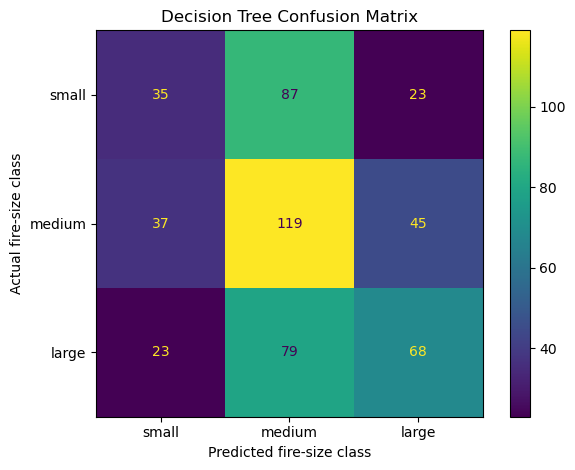

In [43]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

class_order = ["small", "medium", "large"]

ConfusionMatrixDisplay.from_predictions(
    y_test_class,
    test_preds,
    labels=class_order,
    display_labels=class_order,
    values_format="d"
)

plt.title("Decision Tree Confusion Matrix")
plt.xlabel("Predicted fire-size class")
plt.ylabel("Actual fire-size class")
plt.tight_layout()
plt.show()